In [1]:
!pip install -q numpy==2.1.0 opencv-python-headless==4.10.0.84 albumentations==2.0.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.1.0 which is incompatible.


In [2]:
import numpy as np
import pandas as pd
import cv2
import os

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 2.0.2
OpenCV: 4.10.0


In [3]:
!pip install kaggle

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d divg07/casia-20-image-tampering-detection-dataset

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/divg07/casia-20-image-tampering-detection-dataset
License(s): unknown
100% 2.56G/2.56G [00:33<00:00, 80.9MB/s]



In [5]:
!unzip casia-20-image-tampering-detection-dataset.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_arc00045_arc00046_10084.tif  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_arc00045_arc00071_10087.tif  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_arc00046_arc00045_10083.tif  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_arc00054_cha00085_11922.jpg  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_arc00071_arc00045_10085.tif  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_arc00073_arc00072_10267.tif  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_arc00088_arc00064_10394.tif  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_art00012_art00013_11812.jpg  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_art00014_art00013_11836.jpg  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_art00058_art00049_10529.tif  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_art00067_ani00093_11801.jpg  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_art00067_ani00095_11803.jpg  
  inflating: /content/CASIA2/Tp/Tp_D_CRN_M_N_art0

In [6]:
img = np.zeros((100, 100, 3), dtype=np.uint8)
cv2.imwrite("test.jpg", img)

print("Test image created successfully")

Test image created successfully


In [7]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/CASIA2"))

['.config', 'drive', 'casia-20-image-tampering-detection-dataset.zip', 'CASIA2', 'test.jpg', 'sample_data']
['CASIA 2 Groundtruth', 'Au', 'Tp']


In [8]:
import os

print(os.listdir('/content'))

['.config', 'drive', 'casia-20-image-tampering-detection-dataset.zip', 'CASIA2', 'test.jpg', 'sample_data']


In [9]:
import os

base_path = "/content/CASIA2"

path_au = os.path.join(base_path, "Au")
path_tp = os.path.join(base_path, "Tp")
path_gt = os.path.join(base_path, "CASIA 2 Groundtruth")

print("Au samples:", os.listdir(path_au)[:3])
print("Tp samples:", os.listdir(path_tp)[:3])

Au samples: ['Au_sec_30675.jpg', 'Au_art_30397.jpg', 'Au_pla_30280.jpg']
Tp samples: ['Tp_S_NND_S_N_cha20040_cha20040_02039.tif', 'Tp_D_NRN_S_N_cha00084_ani00081_00404.tif', 'Tp_S_NNN_S_N_pla00094_pla00094_00615.tif']


In [10]:
import cv2
from tqdm import tqdm
import random

# Output dirs
auth_dir = "/content/data/authentic"
tamp_dir = "/content/data/tampered"

os.makedirs(auth_dir, exist_ok=True)
os.makedirs(tamp_dir, exist_ok=True)


def preprocess_and_copy(src_dir, dest_dir, limit=1500, size=(256, 256)):
    files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg', '.png', '.tif'))]

    random.shuffle(files)  # 🔥 avoid ordering bias
    files = files[:limit]

    count = 0

    for f in tqdm(files):
        src_path = os.path.join(src_dir, f)
        dst_path = os.path.join(dest_dir, f.split('.')[0] + ".jpg")

        try:
            img = cv2.imread(src_path)
            if img is None:
                continue

            img = cv2.resize(img, size)

            cv2.imwrite(dst_path, img, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
            count += 1

        except Exception:
            continue

    print(f"✅ Processed {count} images → {dest_dir}")


# Execute
preprocess_and_copy(path_au, auth_dir)
preprocess_and_copy(path_tp, tamp_dir)

100%|██████████| 1500/1500 [00:03<00:00, 474.12it/s]


✅ Processed 1500 images → /content/data/authentic


100%|██████████| 1500/1500 [00:03<00:00, 396.13it/s]

✅ Processed 1500 images → /content/data/tampered


In [11]:
import os

# Correct base path
base_path = "/content/CASIA2"

# Find images
for root, dirs, files in os.walk(base_path):
    images = [f for f in files if f.lower().endswith(('.jpg', '.png', '.tif', '.bmp'))]

    if len(images) > 0:
        print(f"FOUND IMAGES! Path: {root}")
        print(f"Number of images: {len(images)}")
        print(f"Sample filename: {images[0]}\n")


FOUND IMAGES! Path: /content/CASIA2/CASIA 2 Groundtruth
Number of images: 5123
Sample filename: Tp_S_NNN_S_N_cha00001_cha00001_00321_gt.png

FOUND IMAGES! Path: /content/CASIA2/Au
Number of images: 7491
Sample filename: Au_sec_30675.jpg

FOUND IMAGES! Path: /content/CASIA2/Tp
Number of images: 5123
Sample filename: Tp_S_NND_S_N_cha20040_cha20040_02039.tif



In [12]:

from PIL import Image, ImageChops, ImageEnhance
import io

def ela_image(path, quality=90, size=(256, 256)):
    # Open original image
    original = Image.open(path).convert('RGB')
    original = original.resize(size)

    # Save to memory instead of disk
    buffer = io.BytesIO()
    original.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)

    # Reload compressed image
    compressed = Image.open(buffer)

    # Compute difference
    diff = ImageChops.difference(original, compressed)

    # Scale differences
    extrema = diff.getextrema()
    max_diff = max([ex[1] for ex in extrema])

    scale = 255.0 / max_diff if max_diff != 0 else 1

    # Enhance
    ela_img = ImageEnhance.Brightness(diff).enhance(scale)

    return ela_img

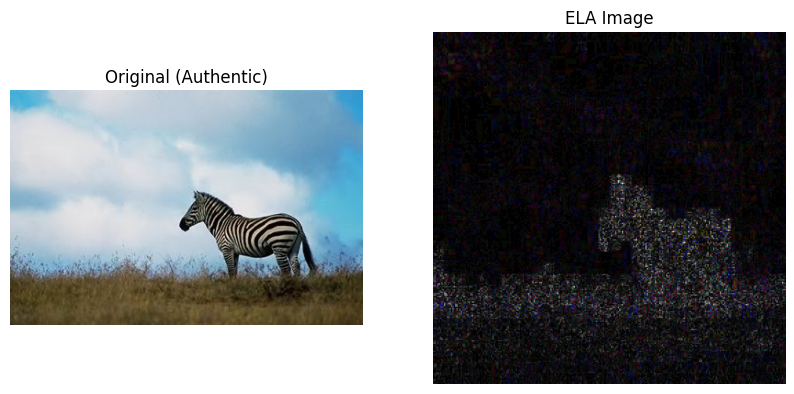

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

# Correct path
path = "/content/CASIA2/Au/Au_ani_00001.jpg"

# Raw image
img = Image.open(path)

# ELA image
ela = ela_image(path, quality=85)

# Plot side-by-side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original (Authentic)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ela)
plt.title("ELA Image")
plt.axis('off')

plt.show()

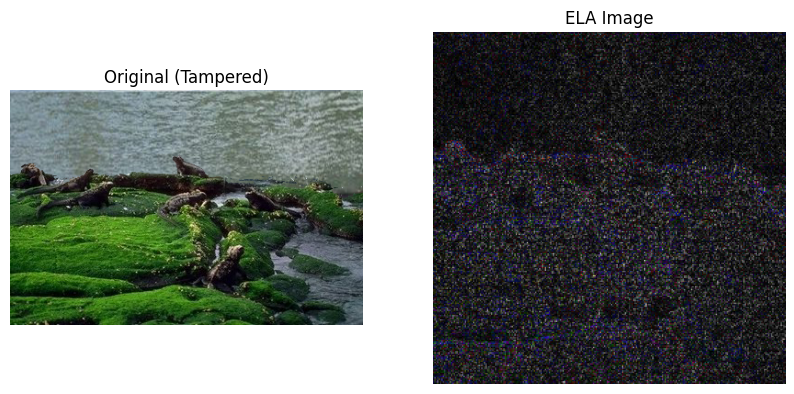

In [14]:
path = "/content/CASIA2/Tp/Tp_D_CND_M_N_ani00018_sec00096_00138.tif"

img = Image.open(path)
ela = ela_image(path, quality=85)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original (Tampered)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ela)
plt.title("ELA Image")
plt.axis('off')

plt.show()

ELA only looks at: 👉 compression differences

So it fails when:

Image saved only once Tampering is subtle Texture is naturally complex (like your zebra case)

👉 It confuses: “high detail” vs “tampering”

In [15]:

def process_folder(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]

    for file in files:
        path = os.path.join(input_dir, file)

        try:
            ela_img = ela_image(path)

            # Ensure saving as JPG (consistent)
            save_name = file.split('.')[0] + ".jpg"
            save_path = os.path.join(output_dir, save_name)

            ela_img.save(save_path)

        except Exception as e:
            print("Error:", file, e)


# ✅ CORRECT COLAB PATHS
base_input = "/content/CASIA2"
base_output = "/content/ELA"

# Process both classes
process_folder(base_input + "/Au", base_output + "/Au")
process_folder(base_input + "/Tp", base_output + "/Tp")

print("✅ ELA generation DONE")

✅ ELA generation DONE


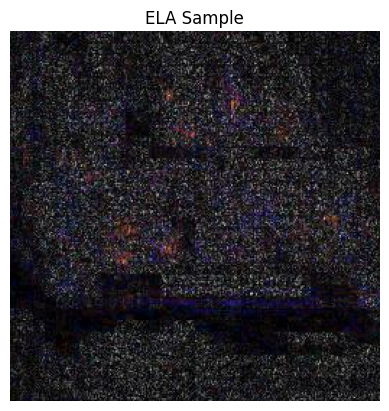

In [16]:
import os
import matplotlib.pyplot as plt
from PIL import Image

sample = "/content/ELA/Au/" + os.listdir("/content/ELA/Au")[0]

img = Image.open(sample)

plt.imshow(img)
plt.axis('off')
plt.title("ELA Sample")
plt.show()

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    '/content/ELA',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    '/content/ELA',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

print(train_data.class_indices)

Found 10049 images belonging to 2 classes.
Found 2511 images belonging to 2 classes.
{'Au': 0, 'Tp': 1}


In [18]:
from tensorflow.keras import layers, models, regularizers

# Define the augmentation sequence
from tensorflow.keras import layers, models, regularizers

model_ela = models.Sequential([
    # 1. Augmentation to force the model to look at the 'noise', not the 'pixels'
    layers.RandomFlip("horizontal_and_vertical", input_shape=(128, 128, 3)),
    layers.RandomRotation(0.1),

    # 2. Layer 1 with BatchNormalization
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # 3. Layer 2 with BatchNormalization
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # 4. Layer 3 with BatchNormalization
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    # 5. Stronger Dropout and Regularization
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.6), # Increased to 0.6 to fight that overfitting!

    layers.Dense(1, activation='sigmoid')
])
from tensorflow.keras.optimizers import Adam

# Default is 0.001. We are moving to 0.0001 (10x slower but 10x more stable)
optimizer = Adam(learning_rate=0.0001)

model_ela.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
import os
from google.colab import drive

# Ensure the mount point is empty before mounting
if os.path.exists('/content/drive'):
    # Only remove if it's not a proper mount, to avoid data loss if already mounted
    # Or, if it's an empty directory from a previous failed mount.
    # A safer approach is to check if it's already mounted before trying to remove.
    # However, since the error is 'contains files', simply removing and remaking is direct.
    print("Cleaning up /content/drive before remounting...")
    !rm -rf /content/drive
    os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive')

Cleaning up /content/drive before remounting...
Mounted at /content/drive


Once your Drive is mounted, you can save your model and other important files there. For example, to save your `best_raw_model_80.h5` model:

In [24]:
import os
import shutil

# Create a directory in your Google Drive to store models, if it doesn't exist
drive_model_path = '/content/drive/MyDrive/Colab_Models'
os.makedirs(drive_model_path, exist_ok=True)

# Save your model to Google Drive
shutil.copy('best_raw_model_80.h5', os.path.join(drive_model_path, 'best_raw_model_80.h5'))
print(f"Model saved to: {os.path.join(drive_model_path, 'best_raw_model_80.h5')}")

# Save the ELA model to Google Drive
shutil.copy('best_model_ela.h5', os.path.join(drive_model_path, 'best_model_ela.h5'))
print(f"Model saved to: {os.path.join(drive_model_path, 'best_model_ela.h5')}")

FileNotFoundError: [Errno 2] No such file or directory: 'best_raw_model_80.h5'

In [23]:
import tensorflow as tf
import os

# This cell should only save the *trained* model locally.
# The actual saving to Google Drive is handled in a separate cell (f797b6a5).
# We don't need to load here, just save the result of the training of model_raw
model_raw.save('best_raw_model_80.h5')
print("Model saved locally as best_raw_model_80.h5")

NameError: name 'model_raw' is not defined

Similarly, you can save your processed image directories (`/content/CLEAN` and `/content/ELA`) to Google Drive. This might take some time depending on the size of the data.

In a new session, after mounting your drive, you can load these back instead of re-running the preprocessing and training:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# Stop training if val_loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# This will wait for 2 epochs of no improvement, then cut the learning rate in half
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
# Save only the BEST version of your model
checkpoint = ModelCheckpoint('best_model_ela.h5', monitor='val_accuracy', save_best_only=True)

history = model_ela.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[lr_reducer, early_stop, checkpoint]
)



In [ ]:
val_loss, val_acc = model_ela.evaluate(val_data)
print("Validation Accuracy:", val_acc)
print(train_data.class_indices)
plt.plot(history.history['accuracy'], label='train_accuracy')

if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.legend()
plt.title('Accuracy Curve')
plt.show()


In [ ]:
import shutil
import os

base_input = "/content/CASIA2"
base_output = "/content/CLEAN"

os.makedirs(base_output + "/Au", exist_ok=True)
os.makedirs(base_output + "/Tp", exist_ok=True)

for cls in ["Au", "Tp"]:
    src = os.path.join(base_input, cls)
    dst = os.path.join(base_output, cls)

    for file in os.listdir(src):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            shutil.copy(os.path.join(src, file), os.path.join(dst, file))

print("✅ Clean dataset ready")
import tensorflow as tf

# 1. Paths
clean_path = "/content/CLEAN"

# 2. Define Training Set (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    clean_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    label_mode='binary'
)

# 3. Define Validation Set (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    clean_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    label_mode='binary'
)

# ==========================================
# ⚡ THE "RAM FASTER" OPTIMIZATION BLOCK ⚡
# ==========================================
AUTOTUNE = tf.data.AUTOTUNE

# .cache() stores the images in RAM after the first epoch (very fast!)
# .shuffle() mixes them up so the model doesn't "memorize" the order
# .prefetch() allows the GPU to work without waiting for the CPU
train_data = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("🚀 RAM Optimization Active. Data is ready for high-speed training!")

In [ ]:
import shutil
import os

# Define the destination path in Google Drive for your processed data
drive_data_path = '/content/drive/MyDrive/Colab_Data/CASIA_Processed'

os.makedirs(drive_data_path, exist_ok=True)

# Copy the CLEAN dataset
print("Copying CLEAN dataset...")
shutil.copytree('/content/CLEAN', os.path.join(drive_data_path, 'CLEAN'), dirs_exist_ok=True)
print("CLEAN dataset copied.")

# Copy the ELA dataset
print("Copying ELA dataset...")
shutil.copytree('/content/ELA', os.path.join(drive_data_path, 'ELA'), dirs_exist_ok=True)
print("ELA dataset copied.")

print("Processed data saved to Google Drive.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import os

# Load the saved model
drive_model_path = '/content/drive/MyDrive/Colab_Models'
model_path = os.path.join(drive_model_path, 'best_raw_model_80.h5')

if os.path.exists(model_path):
    loaded_model = tf.keras.models.load_model(model_path)
    print("Model loaded successfully from Google Drive.")
else:
    print(f"Model not found at {model_path}. Please ensure it was saved correctly.")

# If you saved your processed data, you can copy it back to /content/
# This is optional, you can also directly read from Drive if your data loading functions support it.

# Example of copying processed data back to /content/ (if needed by your training pipeline)
# import shutil
# drive_data_path = '/content/drive/MyDrive/Colab_Data/CASIA_Processed'
# if os.path.exists(drive_data_path):
#     shutil.copytree(os.path.join(drive_data_path, 'CLEAN'), '/content/CLEAN', dirs_exist_ok=True)
#     shutil.copytree(os.path.join(drive_data_path, 'ELA'), '/content/ELA', dirs_exist_ok=True)
#     print("Processed data copied back to /content/.")
# else:
#     print(f"Processed data not found at {drive_data_path}.")

In [25]:
from tensorflow.keras import layers, models

model_raw = models.Sequential([
    layers.Input(shape=(128,128,3)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(), # <--- Adds stability
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Replacing Flatten with GlobalAveragePooling helps prevent the 'Divergence'
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [26]:
model_raw.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# Stop training if val_loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# This will wait for 2 epochs of no improvement, then cut the learning rate in half
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
# Save only the BEST version of your model
checkpoint = ModelCheckpoint('best_model_ela.h5', monitor='val_accuracy', save_best_only=True)

history1 = model_raw.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[lr_reducer, early_stop, checkpoint]
)




Epoch 1/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7314 - loss: 0.5733

315/315 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.7452 - loss: 0.5482 - val_accuracy: 0.4078 - val_loss: 1.3379 - learning_rate: 0.0010
Epoch 2/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.7704 - loss: 0.5041 - val_accuracy: 0.4078 - val_loss: 0.9404 - learning_rate: 0.0010
Epoch 3/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7875 - loss: 0.4781

315/315 ━━━━━━━━━━━━━━━━━━━━ 611s 2s/step - accuracy: 0.7869 - loss: 0.4814 - val_accuracy: 0.5922 - val_loss: 3.2438 - learning_rate: 0.0010
Epoch 4/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 591s 2s/step - accuracy: 0.7957 - loss: 0.4599 - val_accuracy: 0.4373 - val_loss: 0.7086 - learning_rate: 0.0010
Epoch 5/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8076 - loss: 0.4374

315/315 ━━━━━━━━━━━━━━━━━━━━ 603s 2s/step - accuracy: 0.8048 - loss: 0.4462 - val_accuracy: 0.6145 - val_loss: 0.7218 - learning_rate: 0.0010
Epoch 6/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8029 - loss: 0.4463

315/315 ━━━━━━━━━━━━━━━━━━━━ 601s 2s/step - accuracy: 0.8097 - loss: 0.4371 - val_accuracy: 0.7810 - val_loss: 0.4741 - learning_rate: 0.0010
Epoch 7/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 600s 2s/step - accuracy: 0.8257 - loss: 0.4168 - val_accuracy: 0.6495 - val_loss: 0.6633 - learning_rate: 0.0010
Epoch 8/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8241 - loss: 0.4145

315/315 ━━━━━━━━━━━━━━━━━━━━ 598s 2s/step - accuracy: 0.8263 - loss: 0.4101 - val_accuracy: 0.8053 - val_loss: 0.4407 - learning_rate: 0.0010
Epoch 9/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8336 - loss: 0.3892

315/315 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - accuracy: 0.8331 - loss: 0.3933 - val_accuracy: 0.8100 - val_loss: 0.4029 - learning_rate: 0.0010
Epoch 10/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 595s 2s/step - accuracy: 0.8394 - loss: 0.3767 - val_accuracy: 0.8065 - val_loss: 0.4432 - learning_rate: 0.0010
Epoch 11/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 593s 2s/step - accuracy: 0.8482 - loss: 0.3632 - val_accuracy: 0.5958 - val_loss: 3.0505 - learning_rate: 0.0010
Epoch 12/20
287/315 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8628 - loss: 0.3286

In [ ]:
import matplotlib.pyplot as plt

# 1. Get Class Names (Instead of class_indices)
# The class names are stored in the original dataset object before prefetching
class_names = train_ds.class_names
print("Class Names:", class_names)
# Typically: {'0': 'Au', '1': 'Tp'}

# 2. Plotting the Accuracy Curve
plt.figure(figsize=(8, 4))
plt.plot(history1.history['accuracy'], label='train_accuracy', marker='o')
plt.plot(history1.history['val_accuracy'], label='val_accuracy', marker='s')

plt.title('AuthentiScan AI: Raw Stream Training Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 3. Plotting the Loss Curve (Expert move for your report)
plt.figure(figsize=(8, 4))
plt.plot(history1.history['loss'], label='train_loss', color='red')
plt.plot(history1.history['val_loss'], label='val_loss', color='darkred')
plt.title('Model Loss (Error Rate)')
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf
import os

# This cell should only save the *trained* model locally.
# The actual saving to Google Drive is handled in a separate cell (f797b6a5).
# We don't need to load here, just save the result of the training of model_raw
model_raw.save('best_raw_model_80.h5')
print("Model saved locally as best_raw_model_80.h5")

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =========================
# PARAMETERS
# =========================
img_size = (128, 128)
batch_size = 32

# =========================
# DATA GENERATORS
# =========================
datagen = ImageDataGenerator(rescale=1./255)

raw_gen = datagen.flow_from_directory(
    '/content/CLEAN',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

ela_gen = datagen.flow_from_directory(
    '/content/ELA',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# =========================
# DUAL GENERATOR
# =========================
def dual_generator(raw_gen, ela_gen):
    while True:
        x1, y1 = next(raw_gen)
        x2, y2 = next(ela_gen)

        if not np.array_equal(y1, y2):
            raw_gen.reset()
            ela_gen.reset()
            continue

        yield (x1, x2), y1

train_combined = dual_generator(raw_gen, ela_gen)

# =========================
# MODEL (DUAL INPUT)
# =========================

# RAW branch
input_raw = layers.Input(shape=(128,128,3), name="raw_input")

x1 = layers.Conv2D(32, (3,3), activation='relu')(input_raw)
x1 = layers.MaxPooling2D(2,2)(x1)
x1 = layers.Conv2D(64, (3,3), activation='relu')(x1)
x1 = layers.MaxPooling2D(2,2)(x1)
x1 = layers.Flatten()(x1)

# ELA branch
input_ela = layers.Input(shape=(128,128,3), name="ela_input")

x2 = layers.Conv2D(32, (3,3), activation='relu')(input_ela)
x2 = layers.MaxPooling2D(2,2)(x2)
x2 = layers.Conv2D(64, (3,3), activation='relu')(x2)
x2 = layers.MaxPooling2D(2,2)(x2)
x2 = layers.Flatten()(x2)

# Fusion
merged = layers.concatenate([x1, x2])
z = layers.Dense(128, activation='relu')(merged)
z = layers.Dropout(0.5)(z)
output = layers.Dense(1, activation='sigmoid')(z)

# Calculate validation steps
val_steps = min(len(raw_val_gen), len(ela_val_gen))

history = model.fit(
    train_combined,
    steps_per_epoch=steps,
    validation_data=val_combined, # Make sure to create a val_combined generator too!
    validation_steps=val_steps,
    epochs=15 # Increased to 15 because we are using a slower learning rate
)

In [ ]:
import os

print("RAW Au:", len(os.listdir("/content/CLEAN/Au")))
print("RAW Tp:", len(os.listdir("/content/CLEAN/Tp")))

print("ELA Au:", len(os.listdir("/content/ELA/Au")))
print("ELA Tp:", len(os.listdir("/content/ELA/Tp")))

In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

In [ ]:
import os

raw_base = "/content/CLEAN"
ela_base = "/content/ELA"

classes = ["Au", "Tp"]

raw_paths = []
ela_paths = []
labels = []

for cls in classes:
    raw_cls_dir = os.path.join(raw_base, cls)
    ela_cls_dir = os.path.join(ela_base, cls)

    raw_files = sorted(os.listdir(raw_cls_dir))

    for f in raw_files:
        raw_file_path = os.path.join(raw_cls_dir, f)
        ela_file_path = os.path.join(ela_cls_dir, f)

        # ensure matching file exists
        if os.path.exists(ela_file_path):
            raw_paths.append(raw_file_path)
            ela_paths.append(ela_file_path)

            # label: Au=0, Tp=1
            labels.append(0 if cls == "Au" else 1)

In [ ]:
import tensorflow as tf

IMG_SIZE = (128, 128)

def load_image_pair(raw_path, ela_path, label):
    # read images
    raw_img = tf.io.read_file(raw_path)
    raw_img = tf.image.decode_jpeg(raw_img, channels=3)
    raw_img = tf.image.resize(raw_img, IMG_SIZE) / 255.0

    ela_img = tf.io.read_file(ela_path)
    ela_img = tf.image.decode_jpeg(ela_img, channels=3)
    ela_img = tf.image.resize(ela_img, IMG_SIZE) / 255.0

    return (raw_img, ela_img), label


dataset = tf.data.Dataset.from_tensor_slices((raw_paths, ela_paths, labels))

dataset = dataset.map(
    lambda r, e, y: load_image_pair(r, e, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
BATCH_SIZE = 32

dataset = dataset.shuffle(buffer_size=1000)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
dataset_size = len(raw_paths)
train_size = int(0.8 * dataset_size)

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

In [ ]:
plt.plot(history2.history['loss'], label='train_loss')
plt.plot(history2.history['accuracy'], label='train_accuracy')

In [ ]:
plt.plot(history2.history['accuracy'], label='train_accuracy')

if 'val_accuracy' in history2.history:
    plt.plot(history2.history['val_accuracy'], label='val_accuracy')

plt.legend()
plt.title('Accuracy Curve')
plt.show()

In [ ]:
print("Training Accuracy:", history2.history['accuracy'][-1])
